In [1]:
import tesseract_hebrew_utils
import tesseract_sql
import cv2
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np
import copy
from alignment import FeatureExtraction, feature_matching

In [2]:
def disp(images):
    display(Image.fromarray(images))

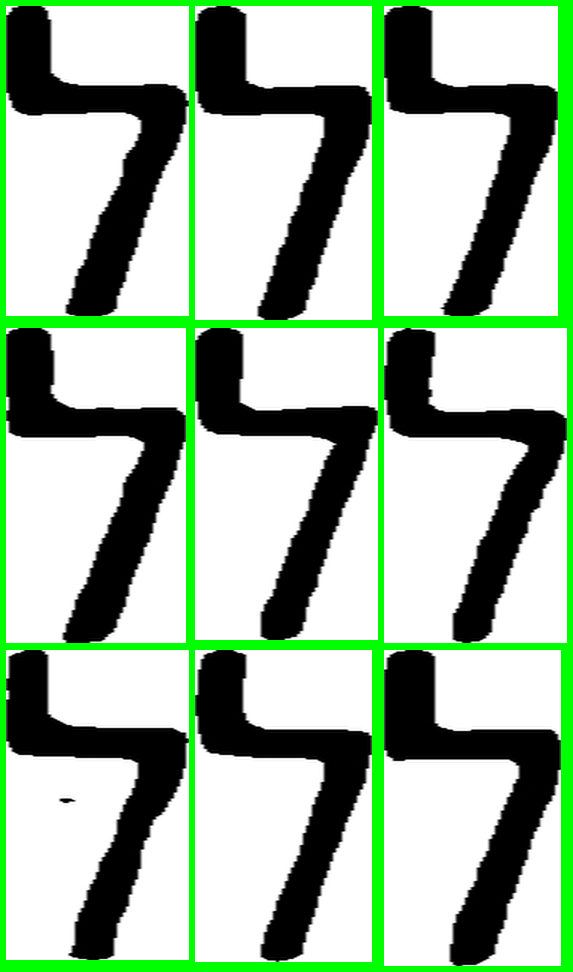

In [11]:
sqlite_db = r'.\letters.sqlite'

db = tesseract_sql.DatabaseManager(sqlite_db)
images = db.read_images_by_text('ל')

images_enlarged = [cv2.resize(img.image, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LANCZOS4)
                   for img in images]
all_images = tesseract_hebrew_utils.embed_images_in_square(images_enlarged, 6)
# view_image_wait_key(all_images)

# plt.imshow(all_images)
# plt.title('my picture')
# plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x / y axis
# plt.show()

disp(all_images)

In [4]:
img1, img2 = images_enlarged[0],images_enlarged[1]
features1 = FeatureExtraction(img1)
features2 = FeatureExtraction(img2)

In [5]:
matches = feature_matching(features1, features2)
matched_image = cv2.drawMatches(img1, features1.kps, \
    img2, features2.kps, matches, None, flags=2)

features0.des is not None and len(features0.des) = 231 > 2
Not appending: Distance is 18.0
Not appending: Distance is 18.0
Not appending: Distance is 18.0
Not appending: Distance is 32.0
Not appending: Distance is 24.0
Not appending: Distance is 26.0
Not appending: Distance is 27.0
Not appending: Distance is 19.0
Not appending: Distance is 27.0
Not appending: Distance is 14.0
Not appending: Distance is 14.0
appending match:  <DMatch 0000026EF097DBF0>
Not appending: Distance is 19.0
Not appending: Distance is 28.0
Not appending: Distance is 0.0
Not appending: Distance is 25.0
Not appending: Distance is 13.0
Not appending: Distance is 18.0
Not appending: Distance is 15.0
Not appending: Distance is 13.0
Not appending: Distance is 23.0
Not appending: Distance is 20.0
Not appending: Distance is 20.0
Not appending: Distance is 27.0
Not appending: Distance is 24.0
Not appending: Distance is 21.0
Not appending: Distance is 23.0
Not appending: Distance is 23.0
Not appending: Distance is 24.0
No

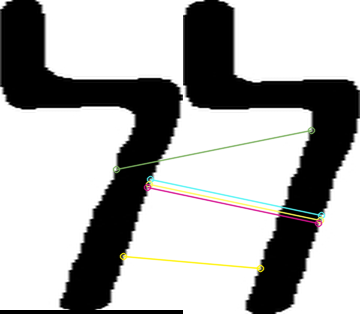

In [6]:
disp(matched_image)

In [7]:
H, _ = cv2.findHomography( features1.matched_pts, features2.matched_pts, cv2.RANSAC, 5.0)
H

array([[-3.69421155e-01, -3.08205763e-01,  1.27746144e+02],
       [-1.23841641e-01, -2.36727103e-01,  8.76916282e+01],
       [-3.23986277e-03, -2.17677524e-03,  1.00000000e+00]])

In [8]:
h, w, c = img2.shape
warped = cv2.warpPerspective(img1, H, (w, h), \
    borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0, 0))
output = np.zeros((h, w, 3), np.uint8)
alpha = 0.5 # warped[:, :, 3] / 255.0
print(img1.shape, img2.shape, warped.shape)
output[:, :, 0] = (1. - alpha) * img1[:, :, 0] + alpha * warped[:, :, 0]
output[:, :, 1] = (1. - alpha) * img1[:, :, 1] + alpha * warped[:, :, 1]
output[:, :, 2] = (1. - alpha) * img1[:, :, 2] + alpha * warped[:, :, 2]

(310, 183, 3) (314, 177, 3) (314, 177, 3)


ValueError: operands could not be broadcast together with shapes (310,183) (314,177) 

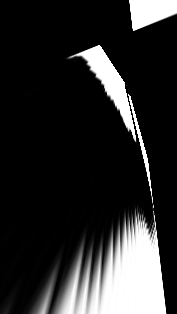

In [9]:
warped = cv2.warpPerspective(img1, H, (w, h), \
    borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0, 0))
disp(warped)